# 08b · GSE65391 · RNA_array · Dynamic Tree Cut on the Ward trees

Reads `modules.rds`, `wgcna_input.rds`, `metadata.rds`.

**Method.** Dynamic Tree Cut (Langfelder P, Zhang B, Horvath S. Defining clusters from a hierarchical
cluster tree: the Dynamic Tree Cut package for R. *Bioinformatics* 2008;24:719–720,
doi:10.1093/bioinformatics/btm563) finds groups from the shape of a hierarchical tree, branch by
branch, instead of cutting the whole tree at one height or at a fixed number of groups. No k is given.

**Trees.** The same as notebook 07: `ward.D2` on Minkowski distance with p = 2, over the 157 first
visits × module hub genes (z-scored per gene), one tree for patients and one for genes.

**Settings.** `method = "hybrid"` (uses the distance matrix as well as the tree), `deepSplit = 2`, PAM
stage on (package default: leftover objects are assigned to the nearest cluster). `deepSplit = 2` is
the value used in endotypes-proteomics (notebook 10).

**The one choice: `minClusterSize`.** It sets the smallest group the method may report. The package
default is 20. endotypes-proteomics chose 5 after a scan (notebook 02). Here the choice is shown as a
scan over 20, 15, 10, 5, 3 and 2 (the smallest possible group), on both axes. For genes, agreement with
the WGCNA modules (adjusted Rand index, ARI; Hubert and Arabie 1985) is reported as a check. Each module
contributes 10 hub genes, so a module can appear as its own group only at sizes of 10 or below.

**Figures** at `minClusterSize = 5`, the endotypes-proteomics value.

In [1]:
source("../src/paths.R")
suppressMessages({library(dynamicTreeCut); library(ComplexHeatmap); library(circlize)})
mods <- readRDS(art("GSE65391", "modules.rds"))
w    <- readRDS(art("GSE65391", "wgcna_input.rds"))
m    <- readRDS(art("GSE65391", "metadata.rds"))[rownames(w$datExpr), ]
hub  <- unlist(lapply(mods$hubs, head, 10))
gene_module <- mods$colors[hub]
X  <- scale(w$datExpr[, hub]); Xc <- pmin(pmax(X, -2.5), 2.5)
d_patients <- dist(X, method = "minkowski", p = 2);    hc_patients <- hclust(d_patients, method = "ward.D2")
d_genes    <- dist(t(X), method = "minkowski", p = 2); hc_genes    <- hclust(d_genes, method = "ward.D2")
ari <- function(a, b) {
  tab <- table(a, b); c2 <- function(x) x * (x - 1) / 2
  e <- sum(c2(rowSums(tab))) * sum(c2(colSums(tab))) / c2(sum(tab))
  (sum(c2(tab)) - e) / ((sum(c2(rowSums(tab))) + sum(c2(colSums(tab)))) / 2 - e)
}
dtc <- function(hc, d, size) cutreeDynamic(hc, distM = as.matrix(d), method = "hybrid", deepSplit = 2,
                                           minClusterSize = size, verbose = 0)

**Scan.** For each minimum size: the number of groups (label 0 = not assigned), group sizes, and for
genes the ARI against the WGCNA modules.

In [2]:
SIZES <- c(20, 15, 10, 5, 3, 2)
scan <- do.call(rbind, lapply(SIZES, function(s) {
  gp <- dtc(hc_patients, d_patients, s); gg <- dtc(hc_genes, d_genes, s)
  data.frame(minClusterSize = s,
             patient_groups = length(setdiff(unique(gp), 0)), patients_unassigned = sum(gp == 0),
             patient_group_sizes = paste(sort(table(gp[gp != 0]), decreasing = TRUE), collapse = " "),
             gene_groups = length(setdiff(unique(gg), 0)), genes_unassigned = sum(gg == 0),
             gene_ARI_vs_modules = round(ari(gg, gene_module), 3))
}))
scan

minClusterSize,patient_groups,patients_unassigned,patient_group_sizes,gene_groups,genes_unassigned,gene_ARI_vs_modules
<dbl>,<int>,<int>,<chr>,<int>,<int>,<dbl>
20,4,0,49 46 41 21,5,0,0.281
15,7,0,30 28 23 21 19 18 18,5,0,0.281
10,9,0,23 21 20 19 18 17 15 13 11,16,0,1.000
5,16,0,19 15 13 11 11 10 10 10 9 9 8 8 7 6 6 5,16,0,1.000
3,16,0,19 15 13 11 11 10 10 10 9 9 8 8 7 6 6 5,16,0,1.000
2,16,0,19 15 13 11 11 10 10 10 9 9 8 8 7 6 6 5,16,0,1.000


**Result.**
- **Genes.** At `minClusterSize` 10 or below, Dynamic Tree Cut returns 16 groups that are exactly the 16
  WGCNA modules (ARI = 1.000), and the answer does not change down to 2. At 15 and 20 it can return only
  5 merged groups (ARI = 0.281), because one module holds 10 hub genes.
- **Patients.** The number of groups grows as the minimum size falls (4 at 20, 7 at 15, 9 at 10) and
  settles at 16 groups (5 to 19 children) from 5 down. **These groups are not evidence of patient
  types.** Dynamic Tree Cut always partitions a tree, and with the PAM stage every child is assigned; it
  cannot return "no groups". The gap statistic (notebook 06a, k = 1) and pvclust (notebook 08d, only
  groups of 2 to 5 children supported) indicate that the children lie on a continuum; the 16 groups
  divide that continuum.

In [3]:
SIZE <- 5
patient_group <- factor(dtc(hc_patients, d_patients, SIZE))
gene_group    <- factor(dtc(hc_genes, d_genes, SIZE))
table(patient_group); table(module = gene_module, dtc_group = gene_group)

patient_group
 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 
19 15 13 11 11 10 10 10  9  9  8  8  7  6  6  5 

              dtc_group
module          1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16
  black         0  0  0  0  0  0  0  0  0  0  0  0 10  0  0  0
  blue          0  0  0  0  0  0  0  0  0 10  0  0  0  0  0  0
  brown         0  0  0  0  0  0 10  0  0  0  0  0  0  0  0  0
  cyan          0  0  0  0  0  0  0  0 10  0  0  0  0  0  0  0
  green         0  0  0  0  0 10  0  0  0  0  0  0  0  0  0  0
  greenyellow   0 10  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  lightcyan    10  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  magenta       0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 10
  midnightblue  0  0  0  0  0  0  0  0  0  0 10  0  0  0  0  0
  pink          0  0  0 10  0  0  0  0  0  0  0  0  0  0  0  0
  purple        0  0  0  0  0  0  0  0  0  0  0  0  0 10  0  0
  red           0  0  0  0  0  0  0  0  0  0  0 10  0  0  0  0
  salmon        0  0 10  0  0  0  0  0  0  0  0  0  0  0  0  0
  tan           0  0  0  0  0  0  0 10  0  0  0  0  0  0  0  0
  turquoise     0  0  0  0  0  

**Result.** At `minClusterSize = 5`, each of the 16 gene groups is one WGCNA module's 10 hub genes.

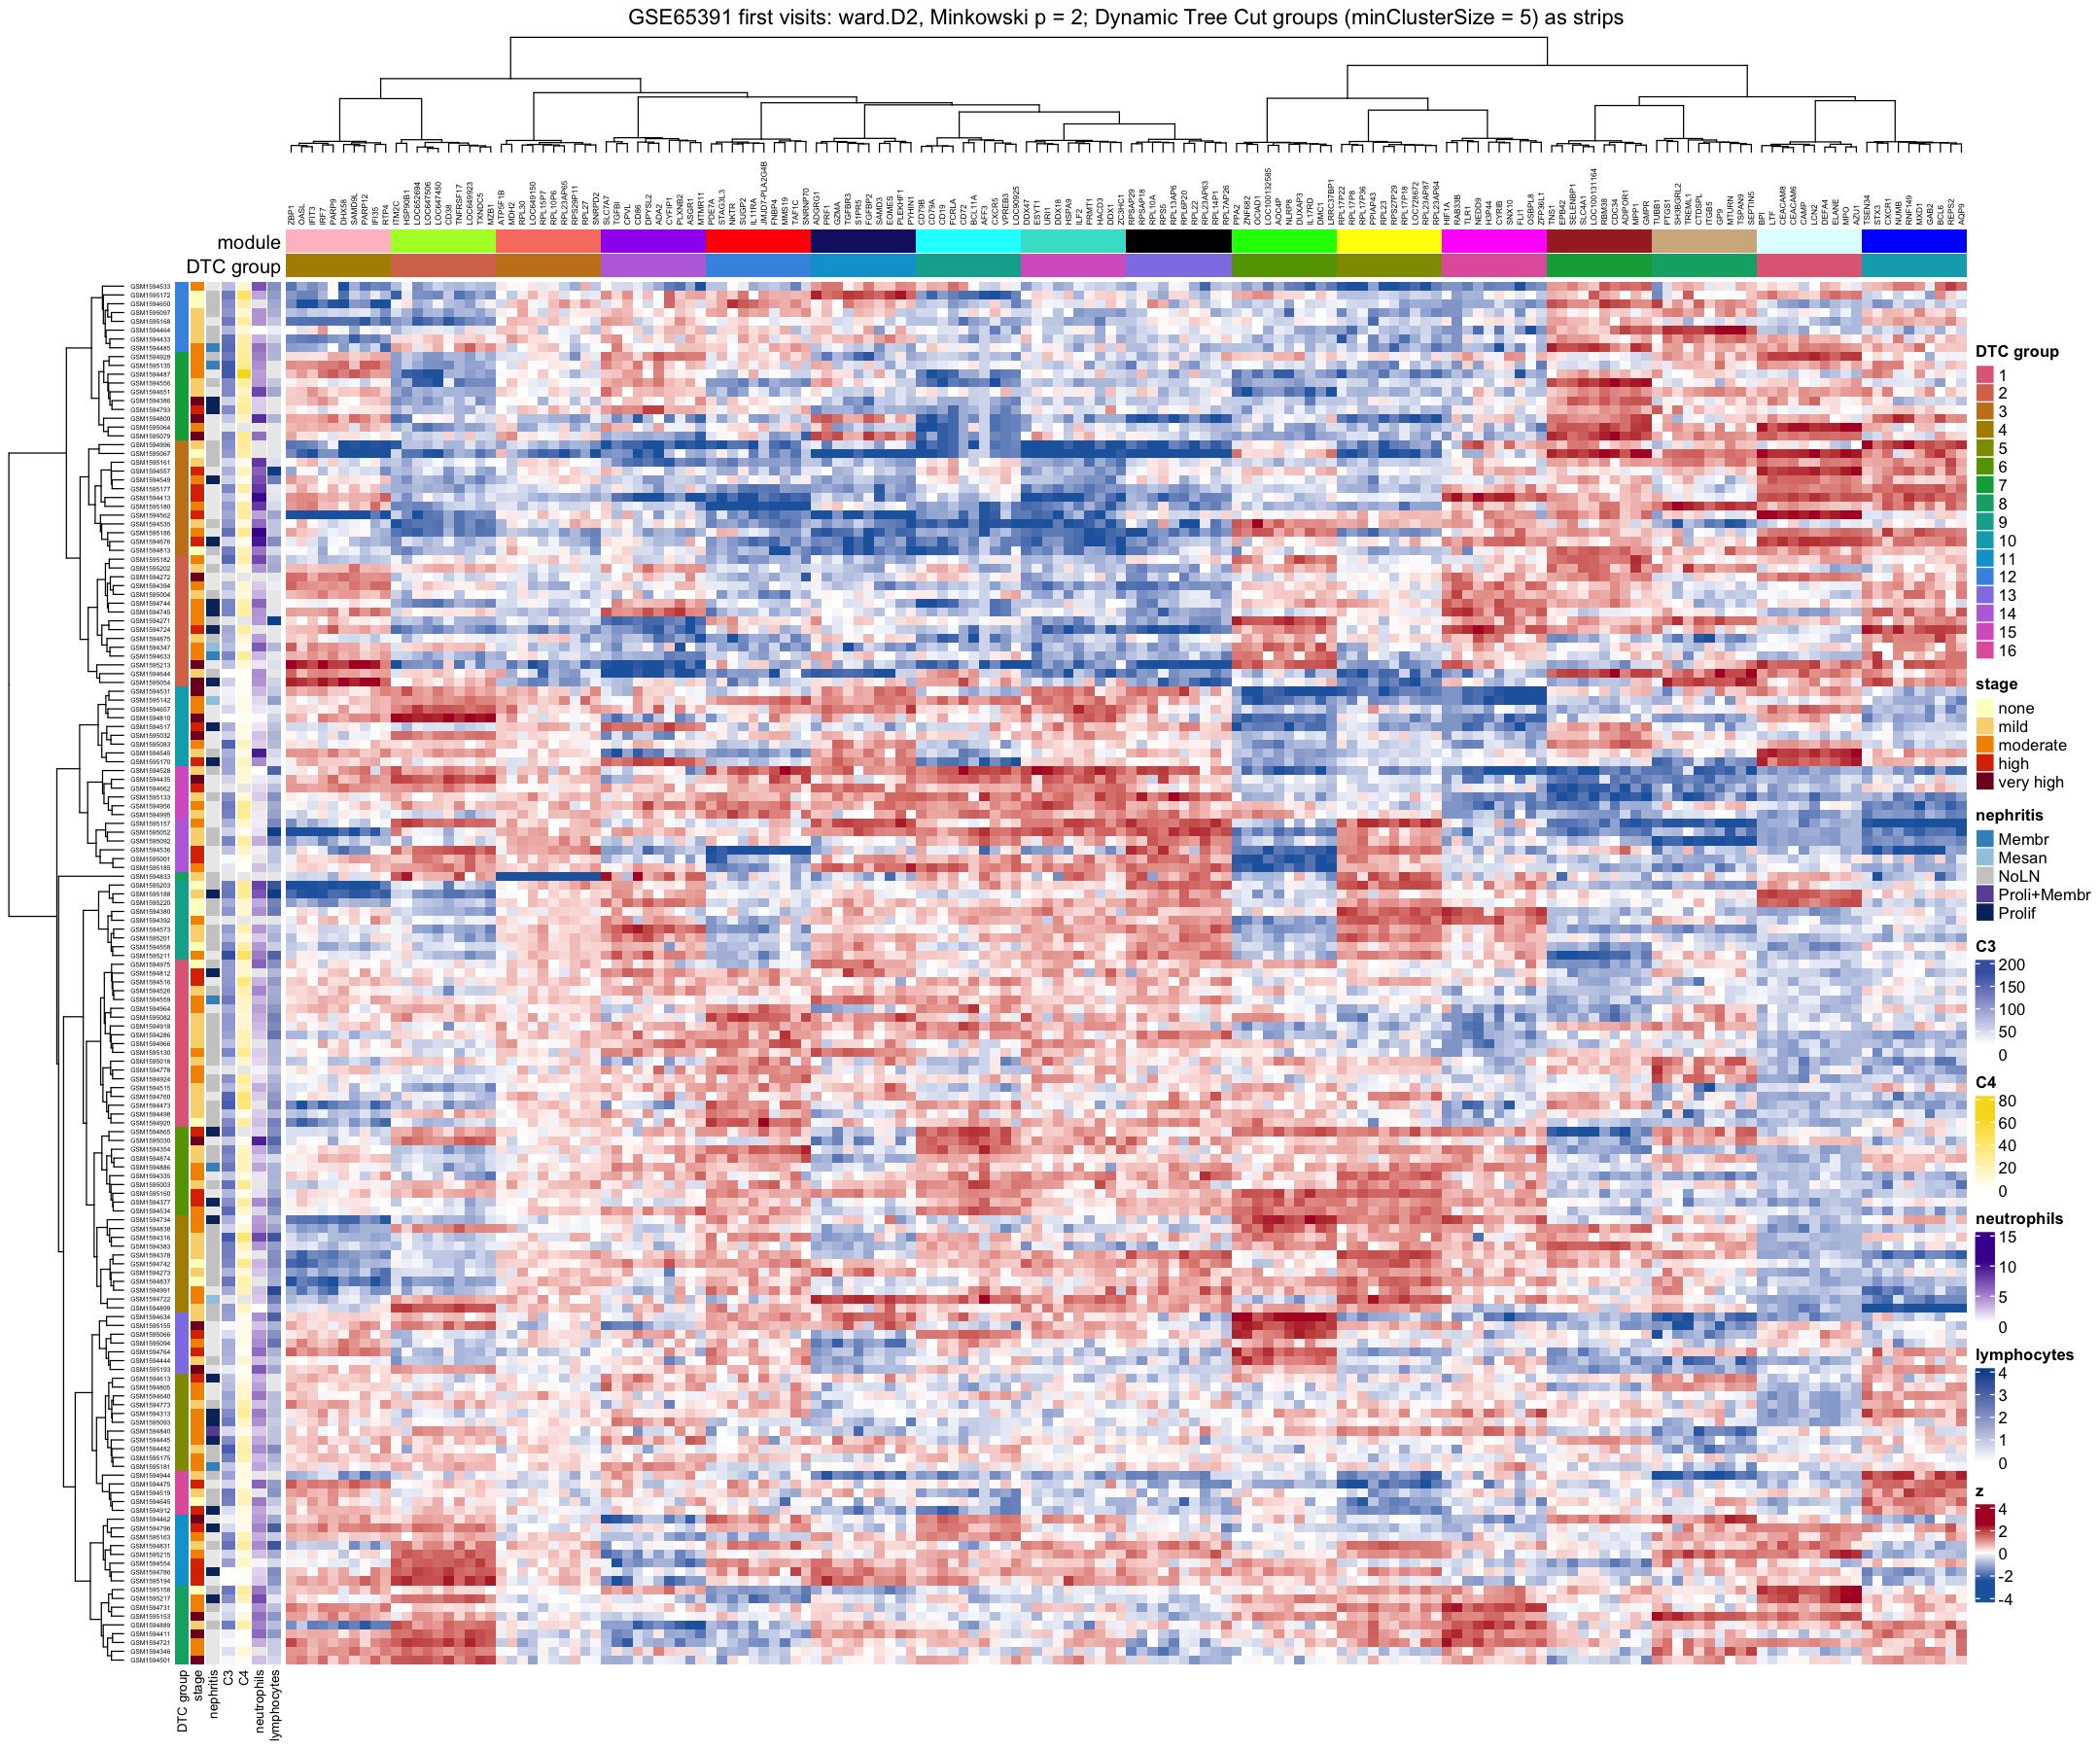

In [4]:
# grey only for label 0 (not assigned); every assigned group gets its own colour
grp_col <- function(f) { lv <- levels(f); cols <- setNames(hcl.colors(length(lv), "Dark 3"), lv); if ("0" %in% lv) cols["0"] <- "grey85"; cols }
left <- rowAnnotation(
  "DTC group" = patient_group, stage = m$stage, nephritis = m$nephritis_class,
  C3 = m$c3, C4 = m$c4, neutrophils = m$neutrophil_count, lymphocytes = m$lymphocyte_count, na_col = "grey92",
  col = list("DTC group" = grp_col(patient_group),
             stage = setNames(hcl.colors(5, "YlOrRd", rev = TRUE), levels(m$stage)),
             nephritis = c(NoLN = "grey80", Mesan = "#9ecae1", Membr = "#4292c6", Prolif = "#08306b", "Proli+Membr" = "#6a51a3"),
             lymphocytes = colorRamp2(c(0, 4), c("white", "#08519c"))),
  annotation_name_gp = gpar(fontsize = 8), simple_anno_size = unit(3, "mm"))
top <- HeatmapAnnotation(module = gene_module, "DTC group" = gene_group,
                         col = list(module = setNames(unique(gene_module), unique(gene_module)), "DTC group" = grp_col(gene_group)),
                         show_legend = c(module = FALSE, "DTC group" = FALSE), annotation_name_side = "left")
options(repr.plot.width = 18, repr.plot.height = 15)
figure <- function() {
  Heatmap(Xc, name = "z", col = colorRamp2(c(-2.5, 0, 2.5), c("#2166AC", "white", "#B2182B")),
          cluster_rows = hc_patients, cluster_columns = hc_genes,
          row_dend_side = "left", column_dend_side = "top",
          row_dend_width = unit(25, "mm"), column_dend_height = unit(25, "mm"),
          show_row_names = TRUE, row_names_side = "left", row_names_gp = gpar(fontsize = 4), column_names_side = "top", column_names_gp = gpar(fontsize = 5),
          top_annotation = top, left_annotation = left,
          column_title = sprintf("GSE65391 first visits: ward.D2, Minkowski p = 2; Dynamic Tree Cut groups (minClusterSize = %d) as strips", SIZE))
}
for (device in c("inline", "png")) {               # shown here, and saved as a 300 dpi PNG
  if (device == "png") png(fig("GSE65391", "08b_GSE65391_RNA_array_dynamic_tree_cut_1.png"), width = 18, height = 15, units = "in", res = 300)
  out <- figure(); if (inherits(out, c("Heatmap", "HeatmapList"))) draw(out)
  if (device == "png") invisible(dev.off())
}